In [1]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns, scipy.stats as stats, pandas as pd, os, glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import rankdata
from scipy.stats import ttest_ind

In [2]:
plt.rcParams.update({
    "axes.titlesize": 18,   # subplot titles
    "axes.labelsize": 16,   # x/y labels
    "xtick.labelsize": 14,  # x ticks
    "ytick.labelsize": 14,  # y ticks
})

In [3]:
df_clean = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
df_clean

,dir_flip,sess_flip,chosen_pos_aligned,div_pos_aligned,stim_pos_aligned,true_class,pred_class,err_type,invalid,missed,...,expName,psychopyVersion,frameRate,expStart,Unnamed: 119,chosen_pos,Unnamed: 112,stim_ranks,resp_ranks,block_name
0,1.0,0.0,-0.044,-0.0,0.02,1,0,-1,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.044,NaN,21.5,10.5,baseline_1.0
1,1.0,0.0,0.040,-0.0,0.38,1,1,0,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.040,NaN,39.5,27.0,baseline_1.0
2,0.0,0.0,-0.044,0.0,-0.02,0,0,0,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.044,NaN,19.5,10.5,baseline_1.0
3,1.0,0.0,-0.068,-0.0,0.06,1,0,-1,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.068,NaN,23.5,8.0,baseline_1.0
4,0.0,0.0,0.008,0.0,0.38,1,1,0,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.008,NaN,39.5,20.0,baseline_1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,1.0,1.0,-0.296,-0.2,-0.22,0,0,0,False,False,...,asymmetry_final,2024.2.4,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.296,NaN,18.5,16.5,pen_comp_1.0
1436,0.0,1.0,0.160,-0.2,0.10,1,1,0,False,False,...,asymmetry_final,2024.2.4,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.160,NaN,35.5,32.0,pen_comp_1.0
1437,0.0,1.0,-0.396,-0.2,-0.30,0,0,0,False,False,...,asymmetry_final,2024.2.4,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.396,NaN,10.5,3.5,pen_comp_1.0
1438,0.0,1.0,-0.344,-0.2,-0.38,0,0,0,False,False,...,asymmetry_final,2024.2.4,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.344,NaN,2.5,11.0,pen_comp_1.0


In [4]:
# a function to choose whether plotting for subj or pop
def get_df(df, subj_or_pop):
    return subj_or_pop, df.copy() if subj_or_pop == 'pop' else df[df['subj'] == subj_or_pop].copy().reset_index(drop=True)

patients = df_clean['subj'].unique().tolist()
n_pts = len(patients)
# pilots = ['A', 'T', 'E']

# test
subj_or_pop, df_analysis = get_df(df_clean, 2)
print(f'\nplotting for pt {subj_or_pop}\nlen(df) = {len(df_analysis)}')
df_analysis


plotting for pt 2
len(df) = 0


,dir_flip,sess_flip,chosen_pos_aligned,div_pos_aligned,stim_pos_aligned,true_class,pred_class,err_type,invalid,missed,...,expName,psychopyVersion,frameRate,expStart,Unnamed: 119,chosen_pos,Unnamed: 112,stim_ranks,resp_ranks,block_name


# 3. checks

In [5]:
# choose what youre plotting
subj_or_pop, df_analysis = get_df(df_clean, 1)

# create column for each phases's duration
expt_phases = ['baseline', 'stim', 'delay', 'task', 'anticipation', 'feedback']
for phase in expt_phases:
    df_analysis[f'{phase}_dur'] = df_analysis[f'{phase}.stopped'] - df_analysis[f'{phase}.started']

# sid, check if these are needed replacements
df_analysis['stim_dur'] = df_analysis['stim.stopped'] - df_analysis['target_stim.started']
# df_analysis['feedback_dur'] = df_analysis['feedback.stopped'] - df_analysis['no_resp_text.started']
df_analysis['feedback_dur'] = df_analysis['feedback.stopped'] - df_analysis['outcome_text.started']

fig, axs = plt.subplots(2, 3, figsize=(15, 4))
axs, ax = axs.flatten(), 0

for expt_phase in expt_phases:

    sns.histplot(df_analysis[f'{expt_phase}_dur'], bins=20, kde=True, ax=axs[ax])
    axs[ax].set(title=expt_phase, xlabel='', ylabel='Count')
    ax += 1

plt.suptitle(f'Task Durations', fontsize=16)
plt.tight_layout()
plt.show()

# print which trials with feedback duration < .99
# short_feedback = df_analysis.loc[df_analysis['feedback_dur'] < 0.998]
# print(f'{len(short_feedback)} trials: {short_feedback.index.tolist()}')

KeyError: 'outcome_text.started'

In [27]:
subj_or_pop, df_analysis = get_df(df_clean, 2)

num_missed = df_analysis['missed'].sum()
num_invalid = df_analysis['invalid'].sum()
num_purely_incorrect = df_analysis['purely_incorrect'].sum()
print(f'patient: {subj_or_pop}')
print(f'\
missed: {num_missed} ({num_missed / 240 * 100:.2f}%),\
 invalid: {num_invalid} ({num_invalid / 240 * 100:.2f}%),\
 incorrect: {num_purely_incorrect} ({num_purely_incorrect / 240 * 100:.2f}%)')

# proportion correct
prop_correct = df_analysis['correct'].mean()
print(f'Proportion correct: {prop_correct:.2f}')

# pearson and spearman correlations between stim_pos_aligned and chosen_pos_aligned
pearson_corr = df_analysis['stim_pos_aligned'].corr(df_analysis['chosen_pos_aligned'], method='pearson')
spearman_corr = df_analysis['stim_pos_aligned'].corr(df_analysis['chosen_pos_aligned'], method='spearman')
print(f'Pearson correlation: {pearson_corr:.2f}')
print(f'Spearman correlation: {spearman_corr:.2f}')

# ensure this is the same
pearson_corr = df_analysis['target_pos'].corr(df_analysis['chosen_pos'], method='pearson')
spearman_corr = df_analysis['target_pos'].corr(df_analysis['chosen_pos'], method='spearman')

print(df_analysis['outcome'].value_counts(), '\n')
print("Outcome counts by block:")
print(df_analysis.groupby('blockN')['outcome'].value_counts())

patient: 2
missed: 0 (0.00%), invalid: 5 (2.08%), incorrect: 70 (29.17%)
Proportion correct: 0.69
Pearson correlation: 0.66
Spearman correlation: 0.65
outcome
-3.0    92
 5.0    73
 3.0    47
-5.0    28
Name: count, dtype: int64 

Outcome counts by block:
blockN  outcome
1.0     -3.0       20
         5.0       20
2.0      5.0       18
        -3.0       17
        -5.0        3
         3.0        2
3.0     -3.0       18
         3.0       11
         5.0        9
        -5.0        2
4.0     -3.0       17
         3.0       13
         5.0        7
        -5.0        3
5.0      3.0       19
        -3.0       17
        -5.0        3
         5.0        1
6.0      5.0       18
        -5.0       17
        -3.0        3
         3.0        2
Name: count, dtype: int64


## plotting vars

In [37]:
conds = ['pen_comp', 'baseline', 'rew_comp']
cond2name = {'pen_comp': 'gain_exp', 'baseline': 'baseline', 'rew_comp': 'loss_exp'}

## NOTE: p_vals sigfig only when i exclude invalid/missed trials

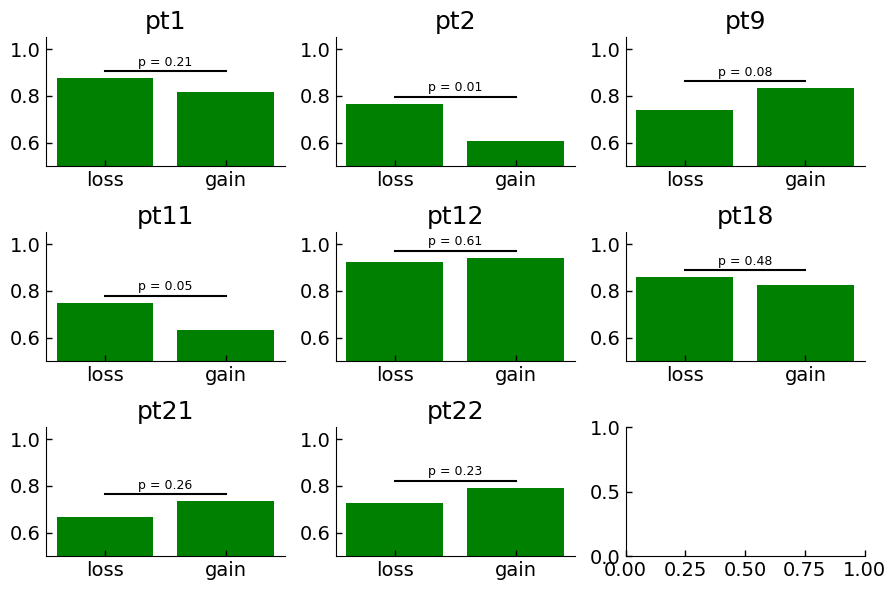

In [35]:
subj_or_pop, df_analysis = get_df(df_clean, 'pop')
# drop missed or invalid trials
# df_analysis = df_analysis[~df_analysis['missed'] & ~df_analysis['invalid']]

n_cols, n_rows = 3, len(patients)//3+1
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axs, ax = axs.flatten(), 0

for subj_idx in range(len(patients)):

    subj_df = df_analysis[df_analysis['subj'] == patients[subj_idx]].copy()
    acc_by_contxt = subj_df.groupby('true_class')['correct'].mean()

    # axs[ax].bar(acc_by_contxt.index, acc_by_contxt.values, color=[pt_colors[subj_idx]])
    axs[ax].bar(acc_by_contxt.index, acc_by_contxt.values, color='g')
    axs[ax].set(title=f'pt{subj_df.iloc[0]["subj"]}',
                ylim=(.5, 1.05), xticks=[0, 1], xticklabels=['loss', 'gain'])

    # stats
    loss_acc = subj_df[subj_df['true_class'] == 0]['correct']
    gain_acc = subj_df[subj_df['true_class'] == 1]['correct']
    # simple independent-samples t-test on trial accuracies
    tval, pval = ttest_ind(loss_acc, gain_acc, equal_var=False)

    # 💬 Add p-value line + text on figure
    y_max = max(acc_by_contxt.values)
    y_line = y_max + 0.03
    axs[ax].plot([0, 1], [y_line, y_line], color='k', lw=1.5)
    axs[ax].text(0.5, y_line + 0.01, f"p = {pval:.2f}", ha='center', va='bottom', fontsize=9)

    ax += 1

for ax in axs:
    ax.tick_params(direction='in', length=4, width=1)
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# plt.suptitle('Categorization Accuracy by Reward Context', fontsize=20)
plt.tight_layout()
plt.show()
# save as eps
# fig.savefig('../../results/figs/sfn/fig3a_accuracy.eps', format='eps', dpi=300)
plt.rcParams['svg.fonttype'] = 'none'  # keeps text editable
fig.savefig('../../results/figs/sfn/fig3a_accuracy.svg', format='svg', dpi=300)

plotting vars

In [38]:
cond2name = {'pen_comp': 'gain_exp', 'baseline': 'baseline', 'rew_comp': 'loss_exp'}
pt_colors = ['g','r','orange','b', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

note that block order for A,C was mistakenly 0,1,2,4,3,5 instead of (0,1,2,3,5,4), and for B,C was 0,2,1,3,4,5

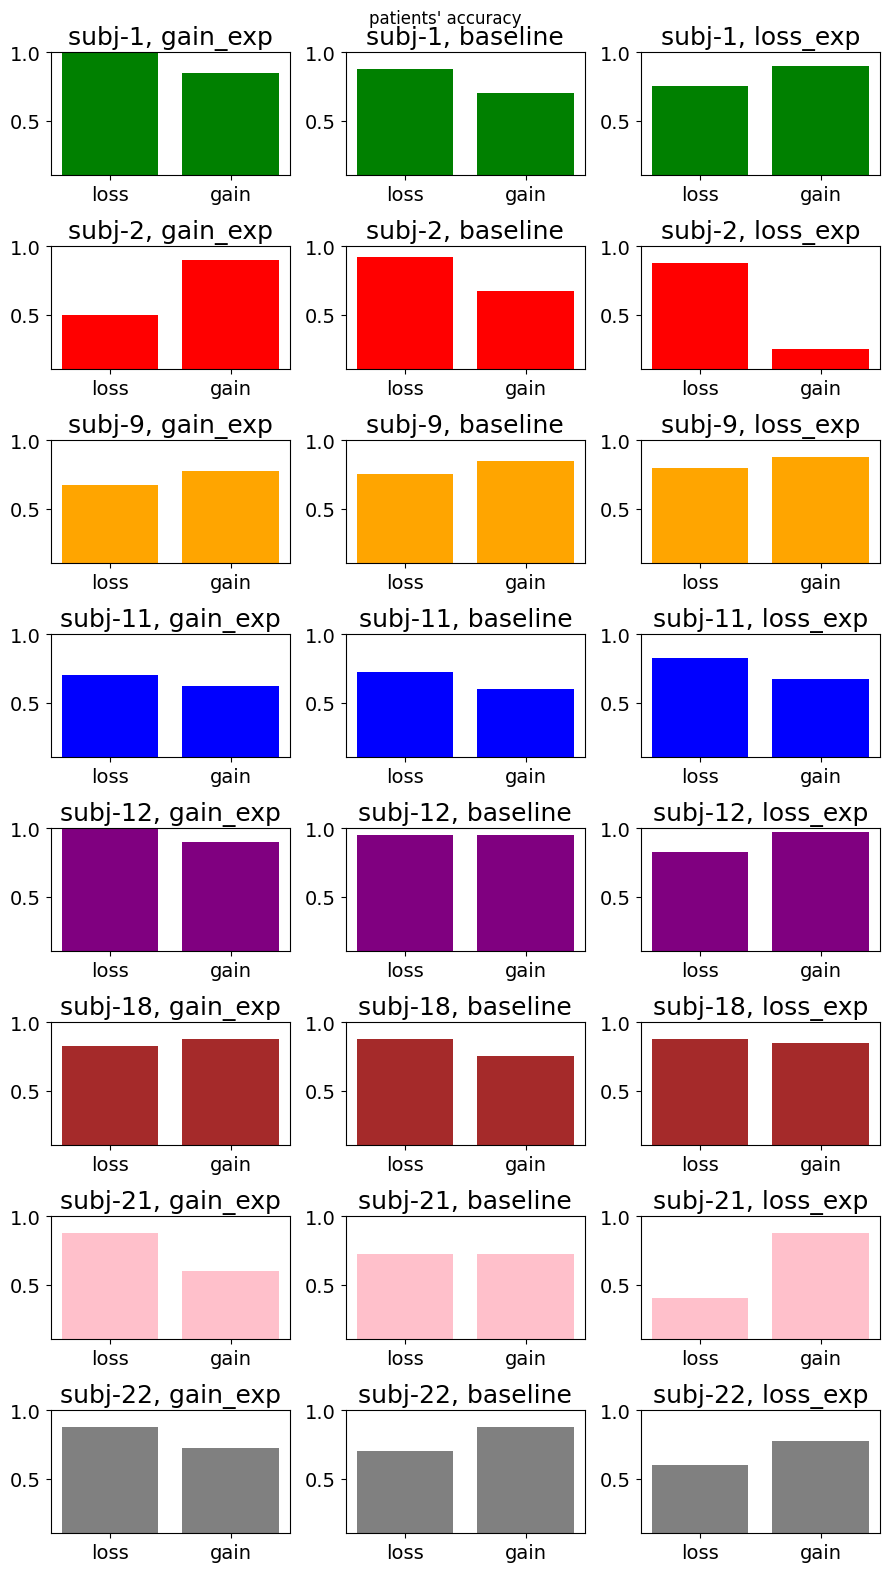

In [41]:
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

n_rows, n_cols = len(patients), 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axs, ax = axs.flatten(), 0

# pilotOrpatient = 1
# subjs2plot = [pilots, patients][pilotOrpatient]
# subj_title = ['pilots', 'patients'][pilotOrpatient]

for pt_idx in range(len(patients)):

    for cond in conds:
        subj_cond_df = df_analysis[(df_analysis['subj'] == patients[pt_idx]) & (df_analysis['condition'] == cond)].copy()
        acc_by_contxt = subj_cond_df.groupby('true_class')['correct'].mean()

        axs[ax].bar(acc_by_contxt.index, acc_by_contxt.values, color=[pt_colors[pt_idx]])
        axs[ax].set(title=f'subj-{patients[pt_idx]}, {cond2name[cond]}', ylim=(.1, 1), xticks=[0, 1], xticklabels=['loss', 'gain'])
        ax += 1

# subplot adjust
plt.suptitle(f'patients\' accuracy')
plt.tight_layout()
plt.show()


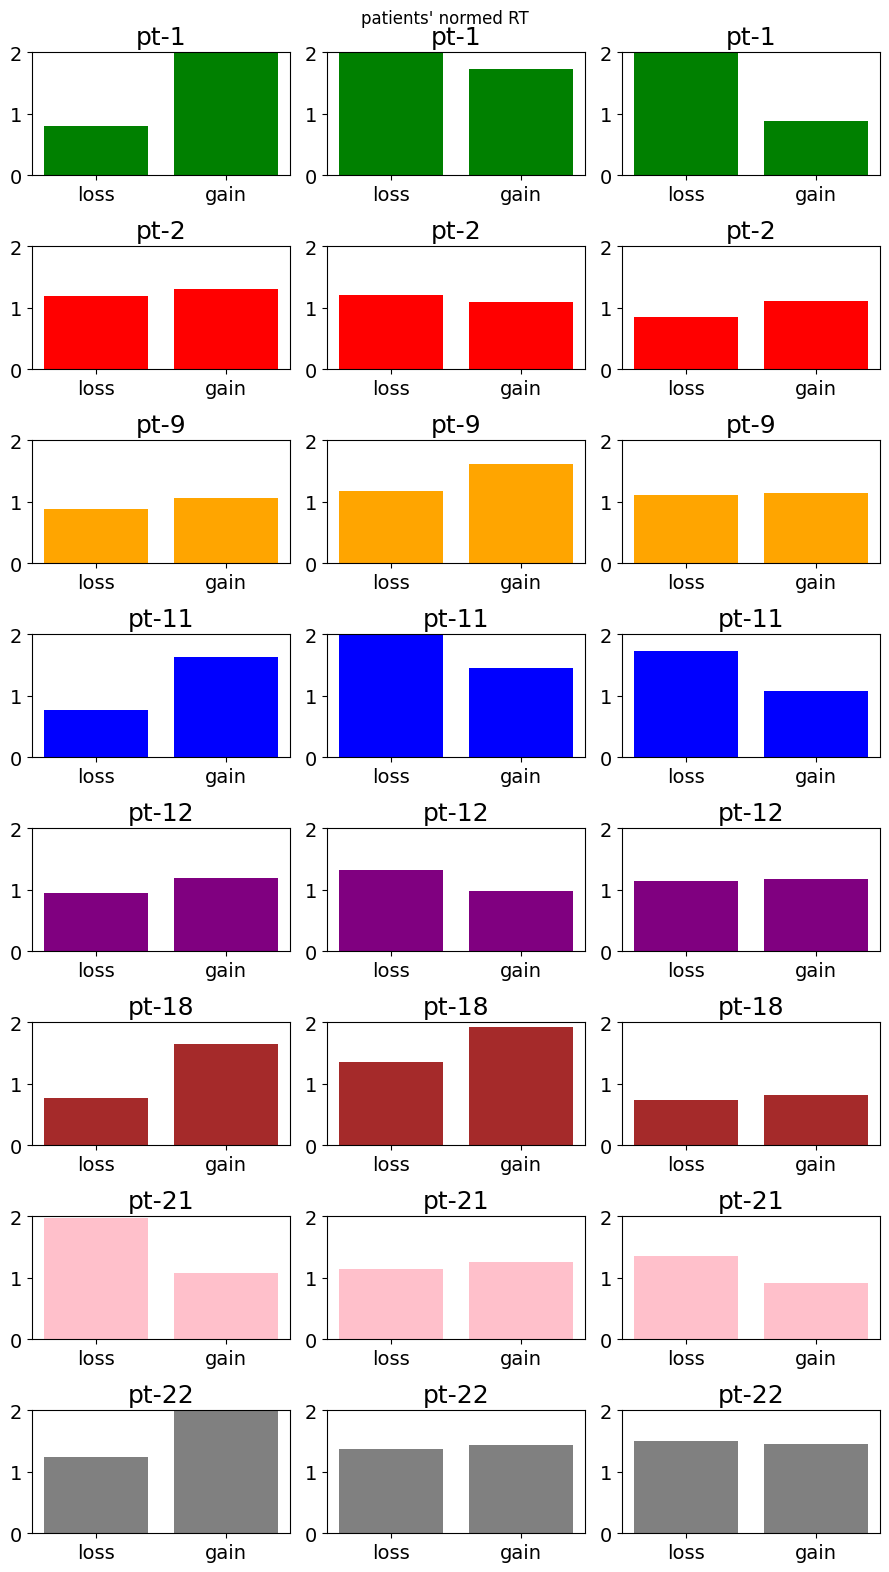

In [72]:
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

n_rows, n_cols = len(patients), 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axs, ax = axs.flatten(), 0

# pilotOrpatient = 1
# subjs2plot = [pilots, patients][pilotOrpatient]
# subj_title = ['pilots', 'patients'][pilotOrpatient]

for pt_idx in range(len(patients)):

    for cond in conds:
        subj_cond_df = df_analysis[(df_analysis['subj'] == patients[pt_idx]) & (df_analysis['condition'] == cond)].copy()
        
        RT_by_cntxt = subj_cond_df.groupby('true_class')['normed_RT'].mean()
        axs[ax].bar(RT_by_cntxt.index, RT_by_cntxt.values, color=[pt_colors[pt_idx]])
        
        axs[ax].set(ylim=(0, 2), xticks=[0, 1], xticklabels=['loss', 'gain'], title=f'pt-{patients[pt_idx]}')
        ax += 1

# subplot adjust
plt.suptitle(f'patients\' normed RT')
plt.tight_layout()
plt.show()

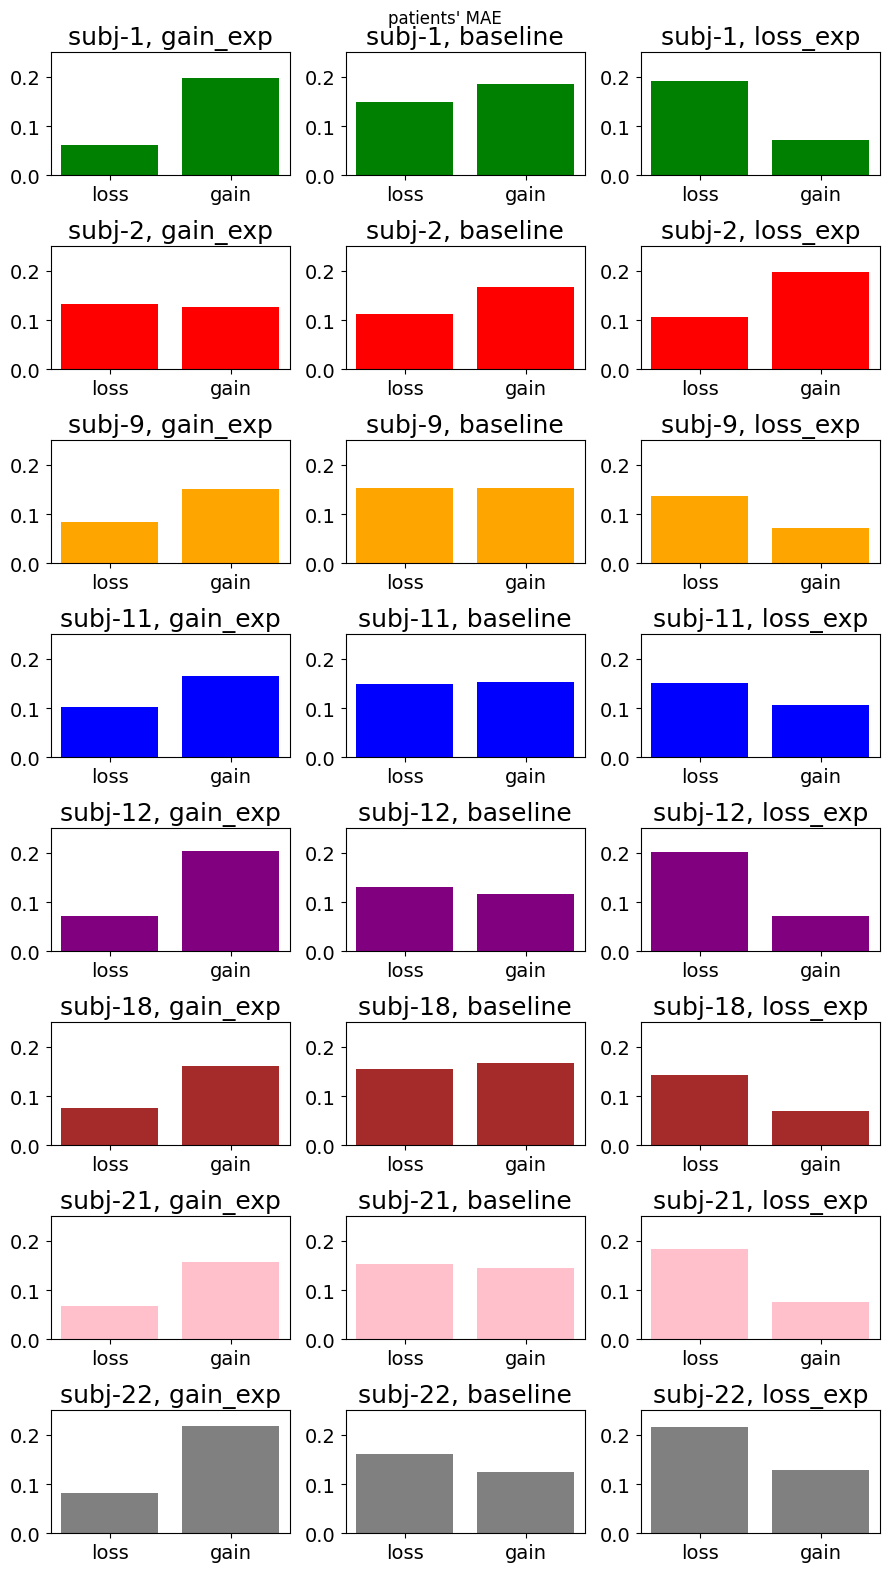

In [43]:
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

n_rows, n_cols = len(patients), 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axs, ax = axs.flatten(), 0

# pilotOrpatient = 1
# subjs2plot = [pilots, patients][pilotOrpatient]
# subj_title = ['pilots', 'patients'][pilotOrpatient]

for pt_idx in range(len(patients)):

    for cond in conds:
        subj_cond_df = df_analysis[(df_analysis['subj'] == patients[pt_idx]) & (df_analysis['condition'] == cond)].copy()
        
        subj_cond_df['abs_err'] = np.abs(subj_cond_df['stim_pos_aligned'] - subj_cond_df['chosen_pos_aligned'])
        err_by_stim = subj_cond_df.groupby('true_class')['abs_err'].mean()
        axs[ax].bar(err_by_stim.index, err_by_stim.values, color=[pt_colors[pt_idx]])

        axs[ax].set(title=f'subj-{patients[pt_idx]}, {cond2name[cond]}', 
                    ylim=(0, .25), xticks=[0, 1], xticklabels=['loss', 'gain'])

        ax += 1

plt.suptitle(f'patients\' MAE')
plt.tight_layout()
plt.show()

## post-error correction

## choice distribution

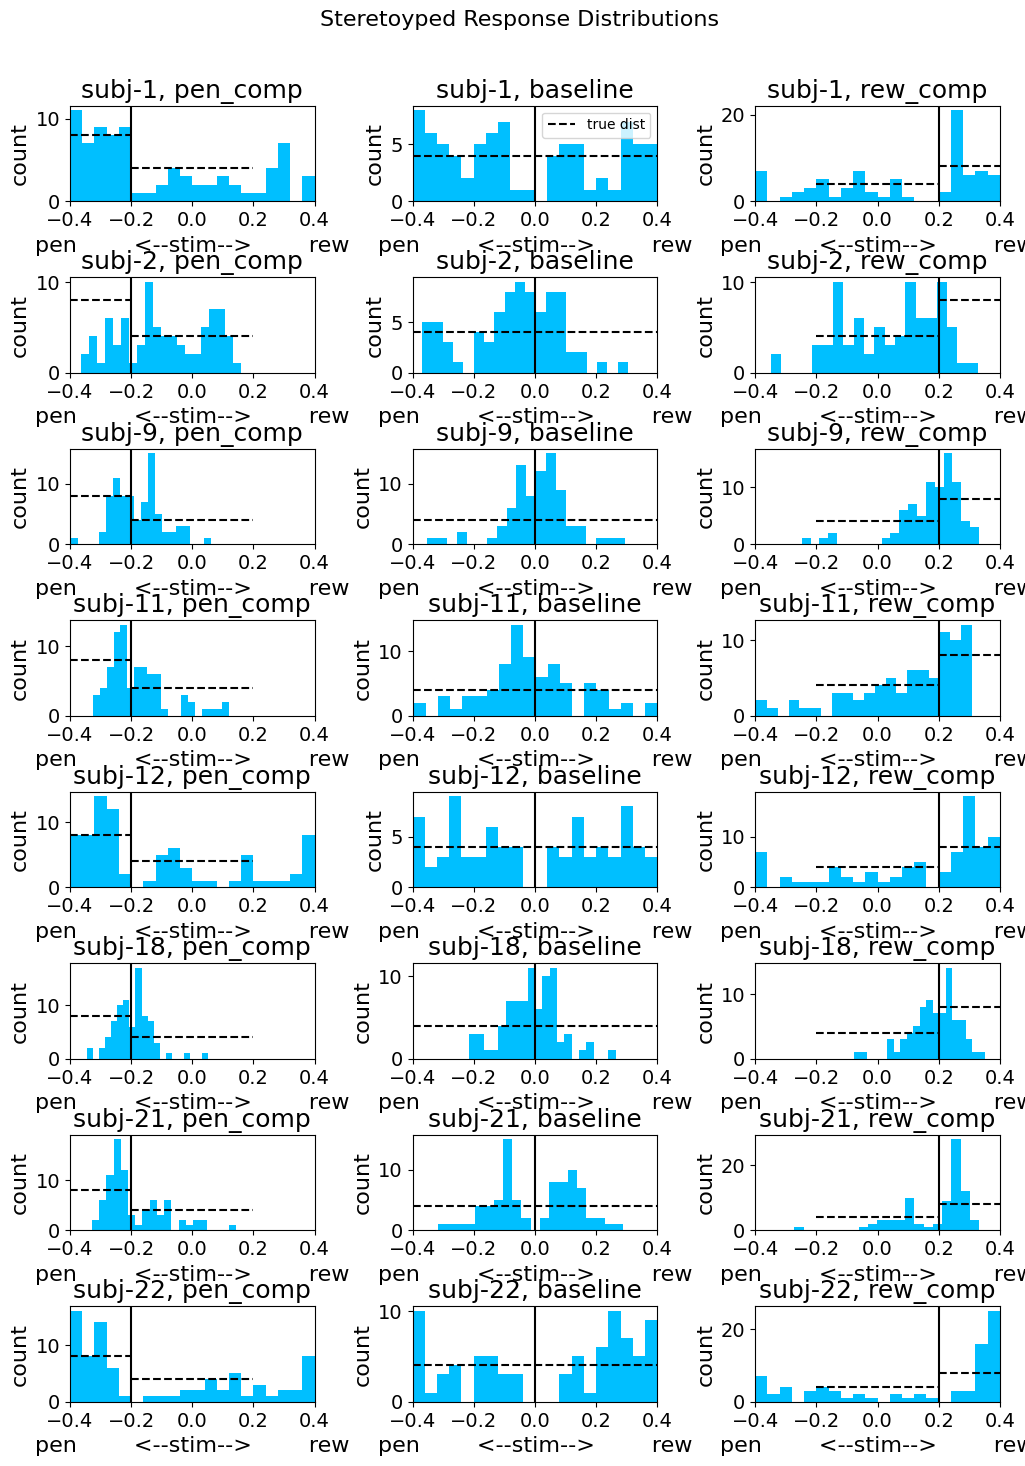

In [44]:
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

subjs = patients
# A. individual plots
fig, axs = plt.subplots(len(subjs), 3, figsize=(4*len(conds), 2*len(subjs)))
axs, ax = axs.flatten(), 0

for subj in subjs:
    for cond in conds:
        subj_cond_df = df_analysis[(df_analysis['subj'] == subj) & (df_analysis['condition'] == cond)].copy()

        axs[ax].set(title=f'subj-{subj}, {cond}',
                    xlabel='pen        <--stim-->        rew', ylabel='count', xlim=(-.4, .4))
        axs[ax].hist(subj_cond_df['chosen_pos_aligned'], bins=20, color='deepskyblue')
        axs[ax].axvline(subj_cond_df['div_pos_aligned'].iloc[0], color='black', linestyle='-')
        
        # true dist line depends on cond
        if cond == 'baseline':
            axs[ax].axhline(4, color='black', linestyle='--', label='true dist')
        elif cond == 'pen_comp':
            axs[ax].hlines(8, -.4, -.2, color='black', linestyle='--', label='true dist')
            axs[ax].hlines(4, -.2, .2, color='black', linestyle='--')
        elif cond == 'rew_comp':
            axs[ax].hlines(4, -.2, .2, color='black', linestyle='--', label='true dist')
            axs[ax].hlines(8, .2, .4, color='black', linestyle='--')
        
        ax += 1

axs[1].legend()
plt.suptitle(f'Steretoyped Response Distributions', fontsize=16)
fig.subplots_adjust(wspace=.4, hspace=.8, top=.92)
plt.show()


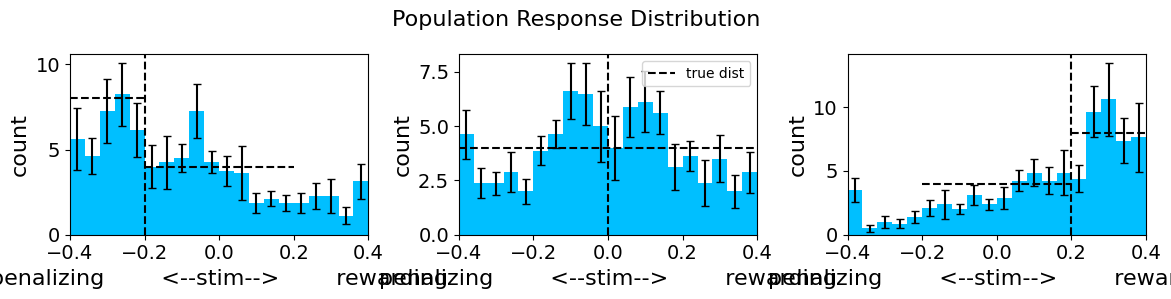

In [45]:
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# B. population
fig, axs = plt.subplots(1, 3, figsize=(4*len(conds), 3))
axs, ax = axs.flatten(), 0

for cond in conds:
    cond_df = df_analysis[df_analysis['condition'] == cond].copy()

    # compute a histogram of responses per subj
    resp_cts = []
    for subj, subj_df in cond_df.groupby('subj'):
        counts, _ = np.histogram(subj_df['chosen_pos_aligned'], bins=20)
        resp_cts.append(counts)
    resp_cts = np.array(resp_cts)

    mean_resp_cts = resp_cts.mean(axis=0)
    sen_resp_cts = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])

    # plot
    axs[ax].bar(np.linspace(-.38,.38,20), mean_resp_cts, width=.04,
                color='deepskyblue', yerr=sen_resp_cts, capsize=3)

    axs[ax].set(xlabel='penalizing        <--stim-->        rewarding',
                ylabel='count', xlim=(-.4, .4))

    # divider
    axs[ax].axvline(cond_df['div_pos_aligned'].iloc[0], color='black', linestyle='--')

    # true dist lines
    if cond == 'baseline':
        axs[ax].axhline(4, color='black', linestyle='--', label='true dist')
    elif cond == 'pen_comp':
        axs[ax].hlines(8, -.4, -.2, color='black', linestyle='--', label='true dist')
        axs[ax].hlines(4, -.2, .2, color='black', linestyle='--')
    elif cond == 'rew_comp':
        axs[ax].hlines(4, -.2, .2, color='black', linestyle='--', label='true dist')
        axs[ax].hlines(8, .2, .4, color='black', linestyle='--')
 
    ax += 1

axs[1].legend()
plt.suptitle(f'Population Response Distribution', fontsize=16)
plt.tight_layout()
plt.show()


## stim vs resp

In [16]:
# # choose what youre plotting
# subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# # plot info
# color_map = {False: 'orange', True: 'deepskyblue'}
# label_map = {False: 'incorrect', True: 'correct'}

# n_rows, n_cols = 4, 3
# fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
# axs, ax = axs.flatten(), 0
# ticks, labels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)

# for subj in patients:

#     for cond in conds:
#         subj_cond_df = df_analysis[(df_analysis['subj'] == subj) & (df_analysis['condition'] == cond)].copy()

#         # SETUP
#         # diagonal for perfect accuracy
#         axs[ax].plot([-.4, .4], [-.4, .4], 'k--', alpha=0.5)

#         # # calculate and plot performance
#         # pearson_r = subj_cond_df['stim_pos_aligned'].corr(subj_cond_df['chosen_pos_aligned'], method='pearson')
#         # accuracy = subj_cond_df['correct'].mean()
#         # axs[ax].text(0.05, 0.95, f'class_acc = {accuracy:.2f}\npearson r = {pearson_r:.2f}', 
#         #             transform=axs[ax].transAxes, verticalalignment='top',
#         #             bbox=dict(boxstyle='round', facecolor='white', alpha=0.4))
            
#         # divider
#         div_pos = subj_cond_df['div_pos_aligned'].iloc[0]
#         axs[ax].axvline(div_pos, color='black', linestyle='-', alpha=0.7)
#         axs[ax].axhline(div_pos, color='black', linestyle='-', alpha=0.7)
        
#         # set
#         # axs[ax].set(title=f'subj-{ax+1}', xlabel='shape position', ylabel='response position',
#         #             xlim=(-.4, .4), ylim=(-.4, .4),
#         #             xticks=ticks, xticklabels=labels, yticks=ticks, yticklabels=labels)

#         axs[ax].set(xlabel='shape position', ylabel='response position',
#                     xlim=(-.4, .4), ylim=(-.4, .4),
#                     xticks=ticks, xticklabels=labels, yticks=ticks, yticklabels=labels)
                
#         # PLOT
#         # points
#         for acc, acc_df in subj_cond_df.groupby('correct'):        
#             axs[ax].scatter(acc_df['stim_pos_aligned'], acc_df['chosen_pos_aligned'],
#                             color=color_map[acc], label=label_map[acc])
                
#         # Calculate mean and SD of chosen position for each stimulus position
#         mean_chosen_per_stim = subj_cond_df.groupby('stim_pos_aligned')['chosen_pos_aligned'].agg(['mean', 'std']).reset_index()
#         mean_chosen_per_stim = mean_chosen_per_stim.sort_values('stim_pos_aligned')
        
#         # mean
#         axs[ax].plot(mean_chosen_per_stim['stim_pos_aligned'], mean_chosen_per_stim['mean'], color='red')
        
#         # err bars
#         axs[ax].errorbar(mean_chosen_per_stim['stim_pos_aligned'], mean_chosen_per_stim['mean'], 
#                         yerr=mean_chosen_per_stim['std'], color= 'red')

#         ax += 1

# axs[1].legend()
# plt.suptitle('Example Patient Responses across Conditions', fontsize=20)
# fig.subplots_adjust(wspace=.8, hspace=.4, top=.94)
# # plt.tight_layout()
# plt.show()


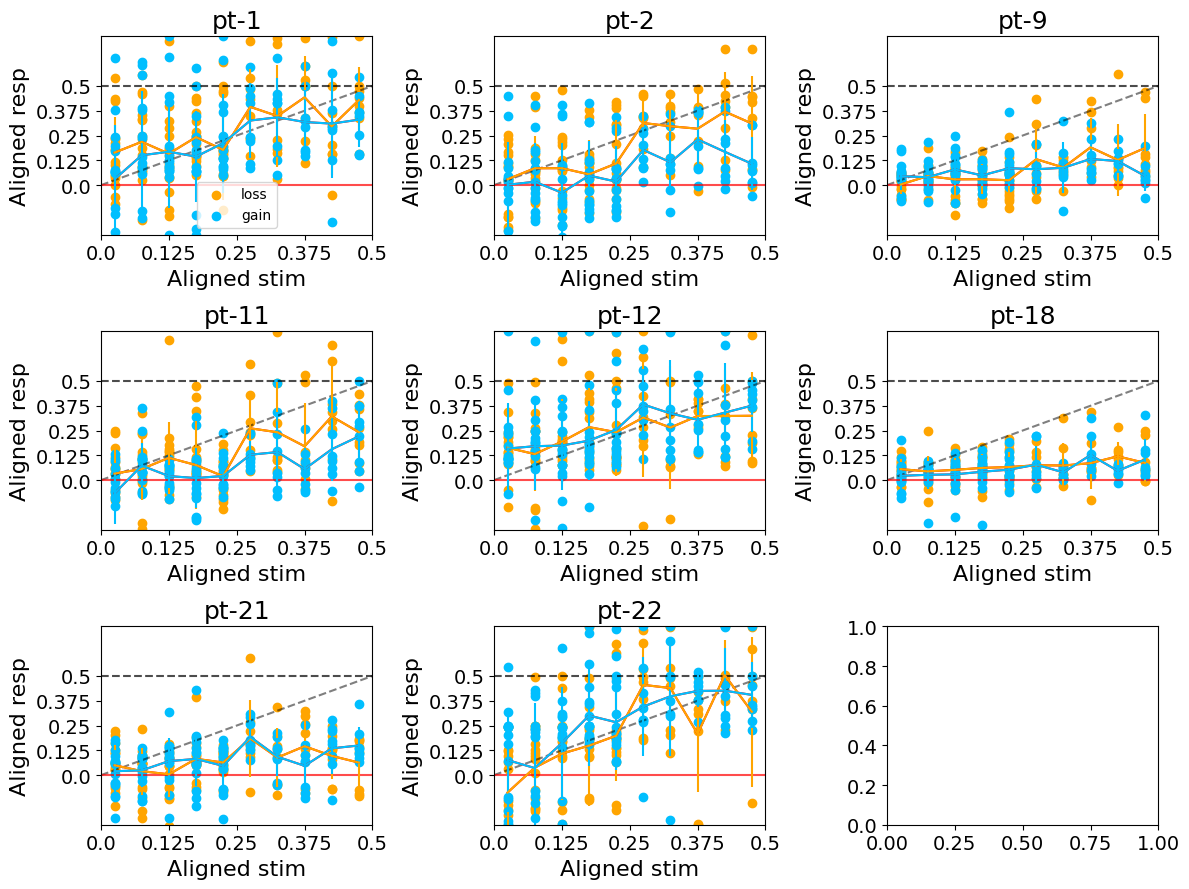

In [48]:
# choose what youre plotting
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# plot info
color_map = {0: 'orange', 1: 'deepskyblue'}
label_map = {0: 'loss', 1: 'gain'}

n_cols, n_rows = 3, len(patients)//3+1
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axs, ax = axs.flatten(), 0
# ticks, labels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)
ticks, labels = np.linspace(0, .4, 5), np.linspace(0, .5, 5)

for subj in patients:

    subj_df = df_analysis[df_analysis['subj'] == subj].copy()

    # for cond in conds:
    #     subj_cond_df = df_analysis[(df_analysis['subj'] == subj) & (df_analysis['condition'] == cond)].copy()

    axs[ax].plot([0, .4], [0, .4], 'k--', alpha=0.5) # diagonal
    axs[ax].axhline(0, color='red', linestyle='-', alpha=0.7) # correct classification
    axs[ax].axhline(.4, color='black', linestyle='--', alpha=0.7) # only in expanded conds

    axs[ax].set(xlabel='Aligned stim', ylabel='Aligned resp', title=f'pt-{subj}',
                xlim=(0, .4), ylim=(-.2, .6),
                xticks=ticks, yticks=ticks, xticklabels=labels, yticklabels=labels)
            
    # scatter
    for cntxt, cntxt_df in subj_df.groupby('true_class'):
                
        axs[ax].scatter(cntxt_df['stim_aligned_to_cntxt'], cntxt_df['resp_aligned_to_cntxt'],
                        color=color_map[cntxt], label=label_map[cntxt])

        # Calculate mean and SD of chosen position for each stimulus position
        mean_chosen_per_stim = cntxt_df.groupby('stim_aligned_to_cntxt')['resp_aligned_to_cntxt'].agg(['mean', 'std']).reset_index()
        mean_chosen_per_stim = mean_chosen_per_stim.sort_values('stim_aligned_to_cntxt')
        
        # mean
        axs[ax].plot(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], color='red')
        
        # err bars
        axs[ax].errorbar(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], 
                        yerr=mean_chosen_per_stim['std'], color=color_map[cntxt])

    axs[0].legend()
    ax += 1

# plt.suptitle('Stimulus vs response for gain vs. loss trials', fontsize=20)
# fig.subplots_adjust(wspace=.8, hspace=.4, top=.94)
plt.tight_layout()
plt.show()


plot RT instead

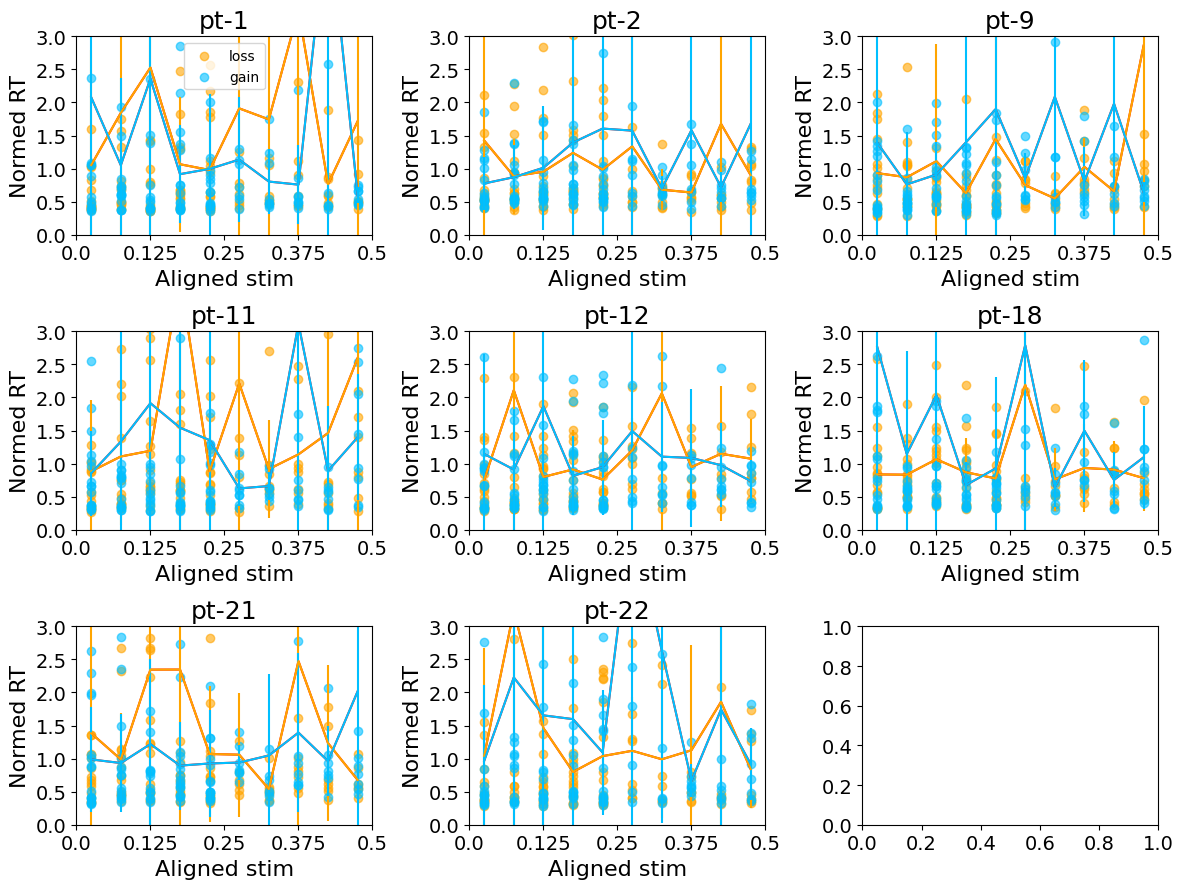

In [50]:
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# plot info
color_map = {0: 'orange', 1: 'deepskyblue'}
label_map = {0: 'loss', 1: 'gain'}

n_cols, n_rows = 3, len(patients)//3+1
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axs, ax = axs.flatten(), 0
ticks, labels = np.linspace(0, .4, 5), np.linspace(0, .5, 5)

for subj in patients:
    subj_df = df_analysis[df_analysis['subj'] == subj].copy()

    axs[ax].set(xlabel='Aligned stim', ylabel='Normed RT',
                title=f'pt-{subj}',
                xlim=(0, .4), ylim=(0, 3),
                xticks=ticks, yticks=np.linspace(0, 3, 7),
                xticklabels=labels)

    for cntxt, cntxt_df in subj_df.groupby('true_class'):
        axs[ax].scatter(cntxt_df['stim_aligned_to_cntxt'], cntxt_df['normed_RT'],
                        color=color_map[cntxt], label=label_map[cntxt], alpha=0.6)

        mean_rt_per_stim = (cntxt_df.groupby('stim_aligned_to_cntxt')['normed_RT']
                             .agg(['mean', 'std'])
                             .reset_index()
                             .sort_values('stim_aligned_to_cntxt'))

        axs[ax].plot(mean_rt_per_stim['stim_aligned_to_cntxt'], mean_rt_per_stim['mean'], color='red')
        axs[ax].errorbar(mean_rt_per_stim['stim_aligned_to_cntxt'], mean_rt_per_stim['mean'], 
                         yerr=mean_rt_per_stim['std'], color=color_map[cntxt])

    axs[0].legend()
    ax += 1

plt.tight_layout()
plt.show()

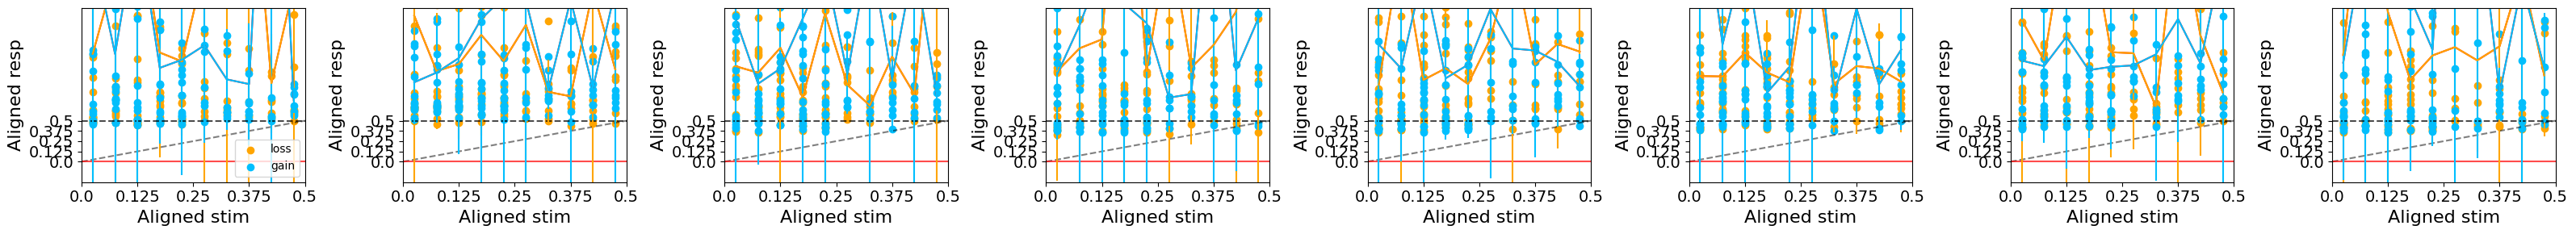

In [19]:
# choose what youre plotting
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# plot info
color_map = {0: 'orange', 1: 'deepskyblue'}
label_map = {0: 'loss', 1: 'gain'}

n_rows, n_cols = len(patients), 3
n_rows, n_cols = 1, len(patients)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axs, ax = axs.flatten(), 0
# ticks, labels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)
ticks, labels = np.linspace(0, .4, 5), np.linspace(0, .5, 5)

for subj in patients:

    subj_df = df_analysis[df_analysis['subj'] == subj].copy()

    # for cond in conds:
    #     subj_cond_df = df_analysis[(df_analysis['subj'] == subj) & (df_analysis['condition'] == cond)].copy()

    axs[ax].plot([0, .4], [0, .4], 'k--', alpha=0.5) # diagonal
    axs[ax].axhline(0, color='red', linestyle='-', alpha=0.7) # correct classification
    axs[ax].axhline(.4, color='black', linestyle='--', alpha=0.7) # only in expanded conds

    axs[ax].set(xlabel='Aligned stim', ylabel='Aligned resp',# title=f'pt-{subj}',
                xlim=(0, .4), ylim=(-.2, 1.5),
                xticks=ticks, yticks=ticks, xticklabels=labels, yticklabels=labels)
            
    # scatter
    for cntxt, cntxt_df in subj_df.groupby('true_class'):
                
        axs[ax].scatter(cntxt_df['stim_aligned_to_cntxt'], cntxt_df['normed_RT'],
                        color=color_map[cntxt], label=label_map[cntxt])

        # Calculate mean and SD of chosen position for each stimulus position
        mean_chosen_per_stim = cntxt_df.groupby('stim_aligned_to_cntxt')['normed_RT'].agg(['mean', 'std']).reset_index()
        mean_chosen_per_stim = mean_chosen_per_stim.sort_values('stim_aligned_to_cntxt')
        
        # mean
        axs[ax].plot(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], color='red')
        
        # err bars
        axs[ax].errorbar(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], 
                        yerr=mean_chosen_per_stim['std'], color=color_map[cntxt])

    axs[0].legend()
    ax += 1

# plt.suptitle('Stimulus vs response for gain vs. loss trials', fontsize=20)
# fig.subplots_adjust(wspace=.8, hspace=.4, top=.94)
plt.tight_layout()
plt.show()


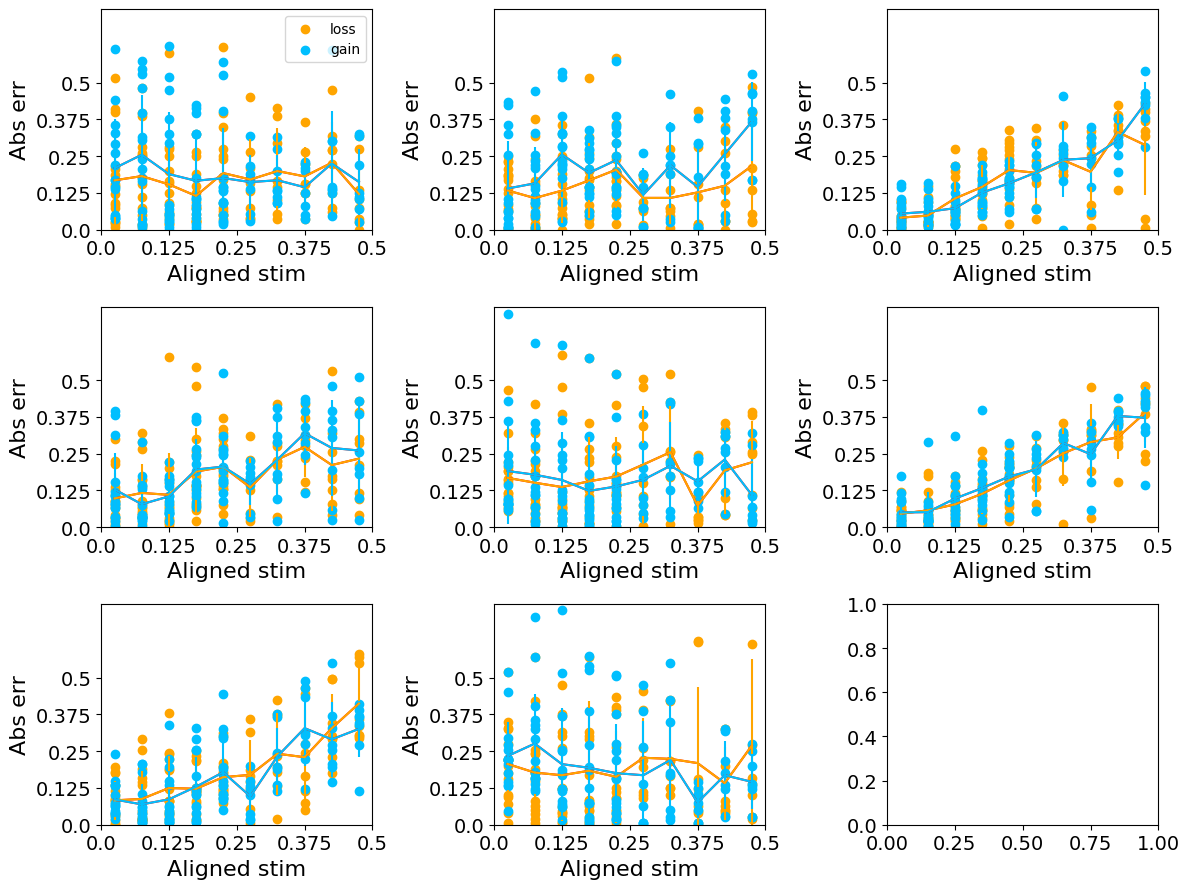

In [51]:
# choose what youre plotting
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# plot info
color_map = {0: 'orange', 1: 'deepskyblue'}
label_map = {0: 'loss', 1: 'gain'}

n_cols, n_rows = 3, len(patients)//3+1
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axs, ax = axs.flatten(), 0
# ticks, labels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)
ticks, labels = np.linspace(0, .4, 5), np.linspace(0, .5, 5)

for subj in patients:

    subj_df = df_analysis[df_analysis['subj'] == subj].copy()

    # for cond in conds:
    #     subj_cond_df = df_analysis[(df_analysis['subj'] == subj) & (df_analysis['condition'] == cond)].copy()

    axs[ax].set(xlabel='Aligned stim', ylabel='Abs err',# title=f'pt-{subj}',
                xlim=(0, .4), ylim=(.0, .6),
                xticks=ticks, yticks=ticks, xticklabels=labels, yticklabels=labels)
            
    # scatter
    for cntxt, cntxt_df in subj_df.groupby('true_class'):
                
        axs[ax].scatter(cntxt_df['stim_aligned_to_cntxt'], cntxt_df['unsigned_err'],
                        color=color_map[cntxt], label=label_map[cntxt])

        # Calculate mean and SD of chosen position for each stimulus position
        mean_chosen_per_stim = cntxt_df.groupby('stim_aligned_to_cntxt')['unsigned_err'].agg(['mean', 'std']).reset_index()
        mean_chosen_per_stim = mean_chosen_per_stim.sort_values('stim_aligned_to_cntxt')
        
        # mean
        axs[ax].plot(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], color='red')
        
        # err bars
        axs[ax].errorbar(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], 
                        yerr=mean_chosen_per_stim['std'], color=color_map[cntxt])

    axs[0].legend()
    ax += 1

# plt.suptitle('Absolute error as a function of class certainty for gain vs. loss trials', fontsize=20)
# fig.subplots_adjust(wspace=.8, hspace=.4, top=.94)
plt.tight_layout()
plt.show()


In [52]:
block_df = df_analysis[df_analysis['blockN'] == 1.0].copy()
print(block_df['stim_aligned_to_cntxt'].value_counts())

stim_aligned_to_cntxt
0.22    32
0.18    32
0.34    32
0.10    32
0.02    32
0.38    32
0.30    32
0.06    32
0.14    32
0.26    32
Name: count, dtype: int64


1.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

2.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.02    4
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

5.0 stim_aligned_to_cntxt
0.02    4
Name: count, dtype: int64

6.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

1.0 stim_aligned_to_cntxt
0.06    2
Name: count, dtype: int64

2.0 stim_aligned_to_cntxt
0.06    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.06    4
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.06    2
Name: count, dtype: int64

5.0 stim_aligned_to_cntxt
0.06    4
Name: count, dtype: int64

6.0 stim_aligned_to_cntxt
0.06    2
Name: count, dtype: int64

1.0 stim_aligned_to_cntxt
0.1    2
Name: count, dtype: int64

2.0 stim_aligned_to_cntxt
0.1    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.1    4
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.1    2
Name: count, dtype: int

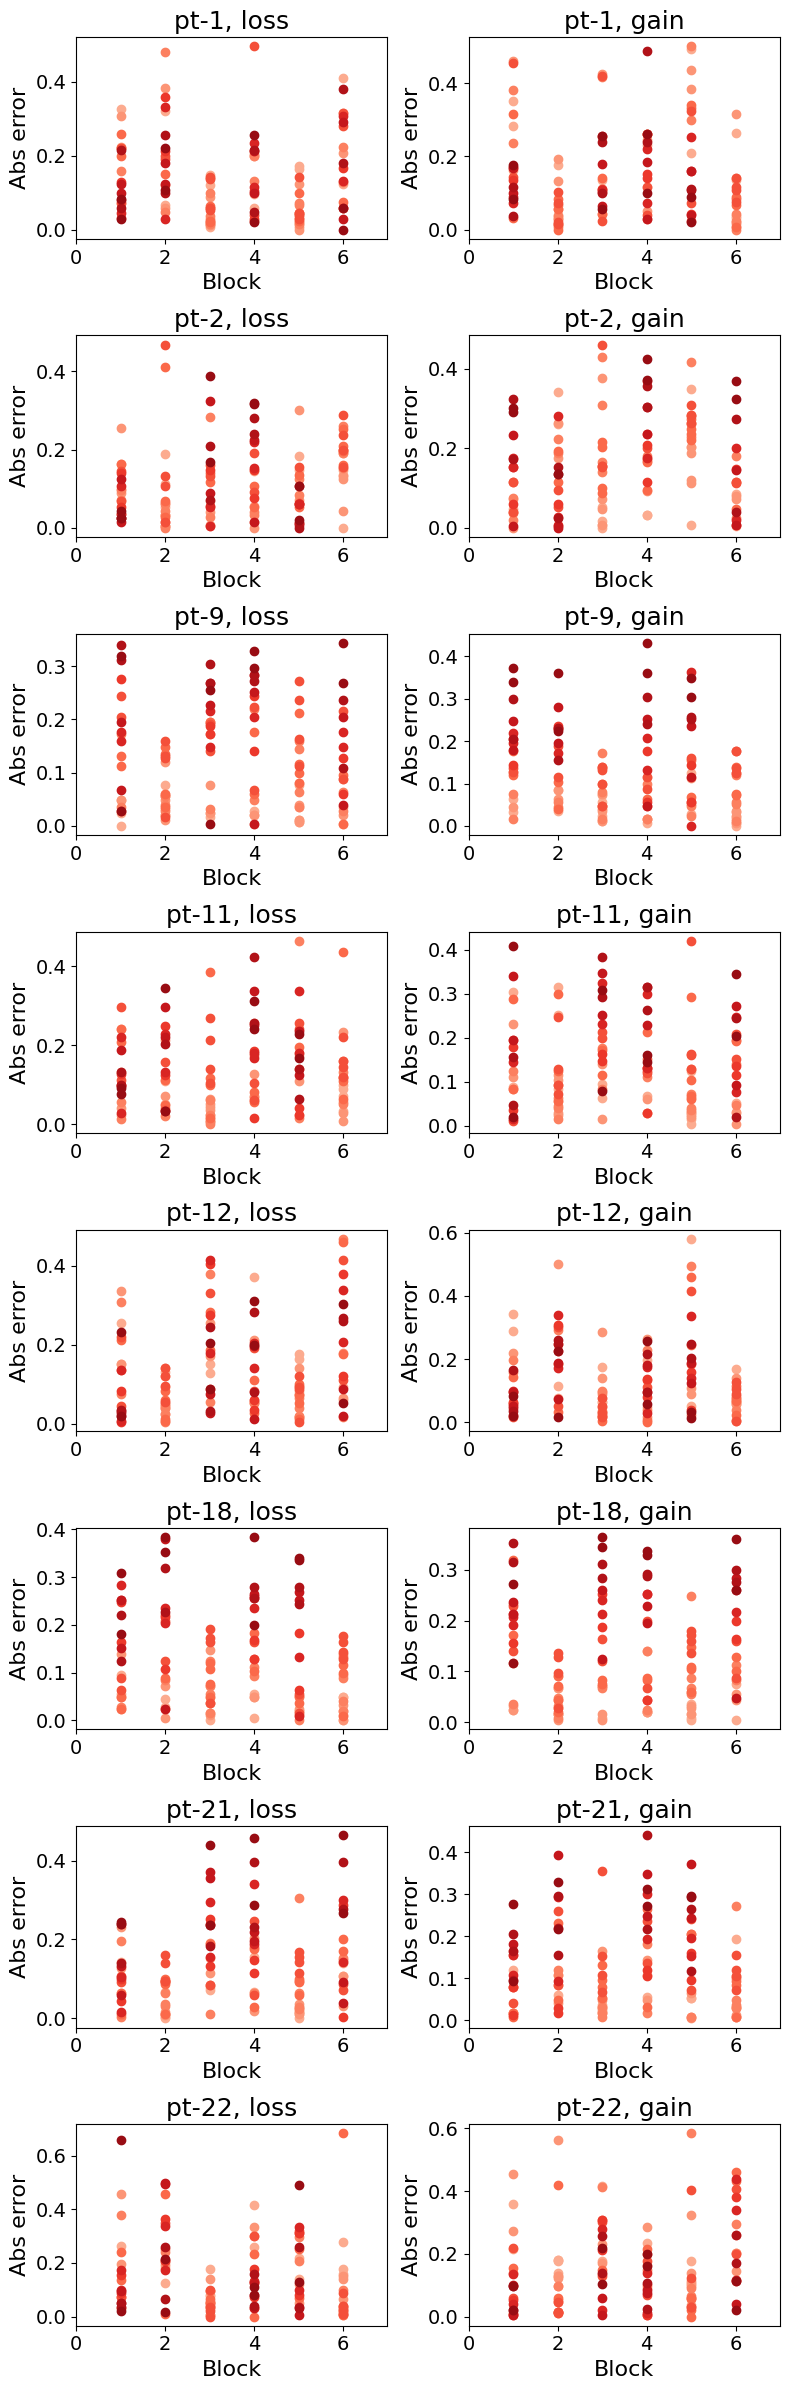

In [53]:
# choose what youre plotting
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# plot info
unique_cntxt_stims = sorted(df_analysis['stim_aligned_to_cntxt'].unique())
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(unique_cntxt_stims)))
color_map = dict(zip(unique_cntxt_stims, colors))
cntxt_rename = {'rew': 'gain', 'pen': 'loss'}

n_rows, n_cols = len(patients), 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axs, ax = axs.flatten(), 0
ticks, labels = np.linspace(0, .4, 5), np.linspace(0, .5, 5)

for subj in patients:

    subj_df = df_analysis[df_analysis['subj'] == subj].copy()

    for cntxt in ['pen', 'rew']: # loss on left, gain on right
        cntxt_df = subj_df[subj_df['valence'] == cntxt].copy()
                    
        # scatter
        for cntxt_stim, cntxt_stim_df in cntxt_df.groupby('stim_aligned_to_cntxt'):

            for block, block_df in cntxt_stim_df.groupby('blockN'):
                print(block, block_df['stim_aligned_to_cntxt'].value_counts(), end='\n\n')

            axs[ax].scatter(cntxt_stim_df['blockN'], cntxt_stim_df['unsigned_err'], color=color_map[cntxt_stim])

            # # Calculate mean and SD of chosen position for each stimulus position
            # mean_chosen_per_stim = cntxt_stim_df.groupby('stim_aligned_to_cntxt')['unsigned_err'].agg(['mean', 'std']).reset_index()
            # mean_chosen_per_stim = mean_chosen_per_stim.sort_values('stim_aligned_to_cntxt')
            
            # # mean
            # axs[ax].plot(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], color='red')
            
            # # err bars
            # axs[ax].errorbar(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], 
            #                 yerr=mean_chosen_per_stim['std'], color=color_map[cntxt_stim])

        axs[ax].set(title=f'pt-{subj}, {cntxt_rename[cntxt]}',
                    xlabel='Block', ylabel='Abs error',
                    xlim=(0, 7))
        # axs[0].legend()
        ax += 1

# fig.subplots_adjust(wspace=.8, hspace=.4, top=.94)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1751602/2225784886.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cond_df['blockN'] = pd.Categorical(cond_df['blockN'], categories=block_order, ordered=True)


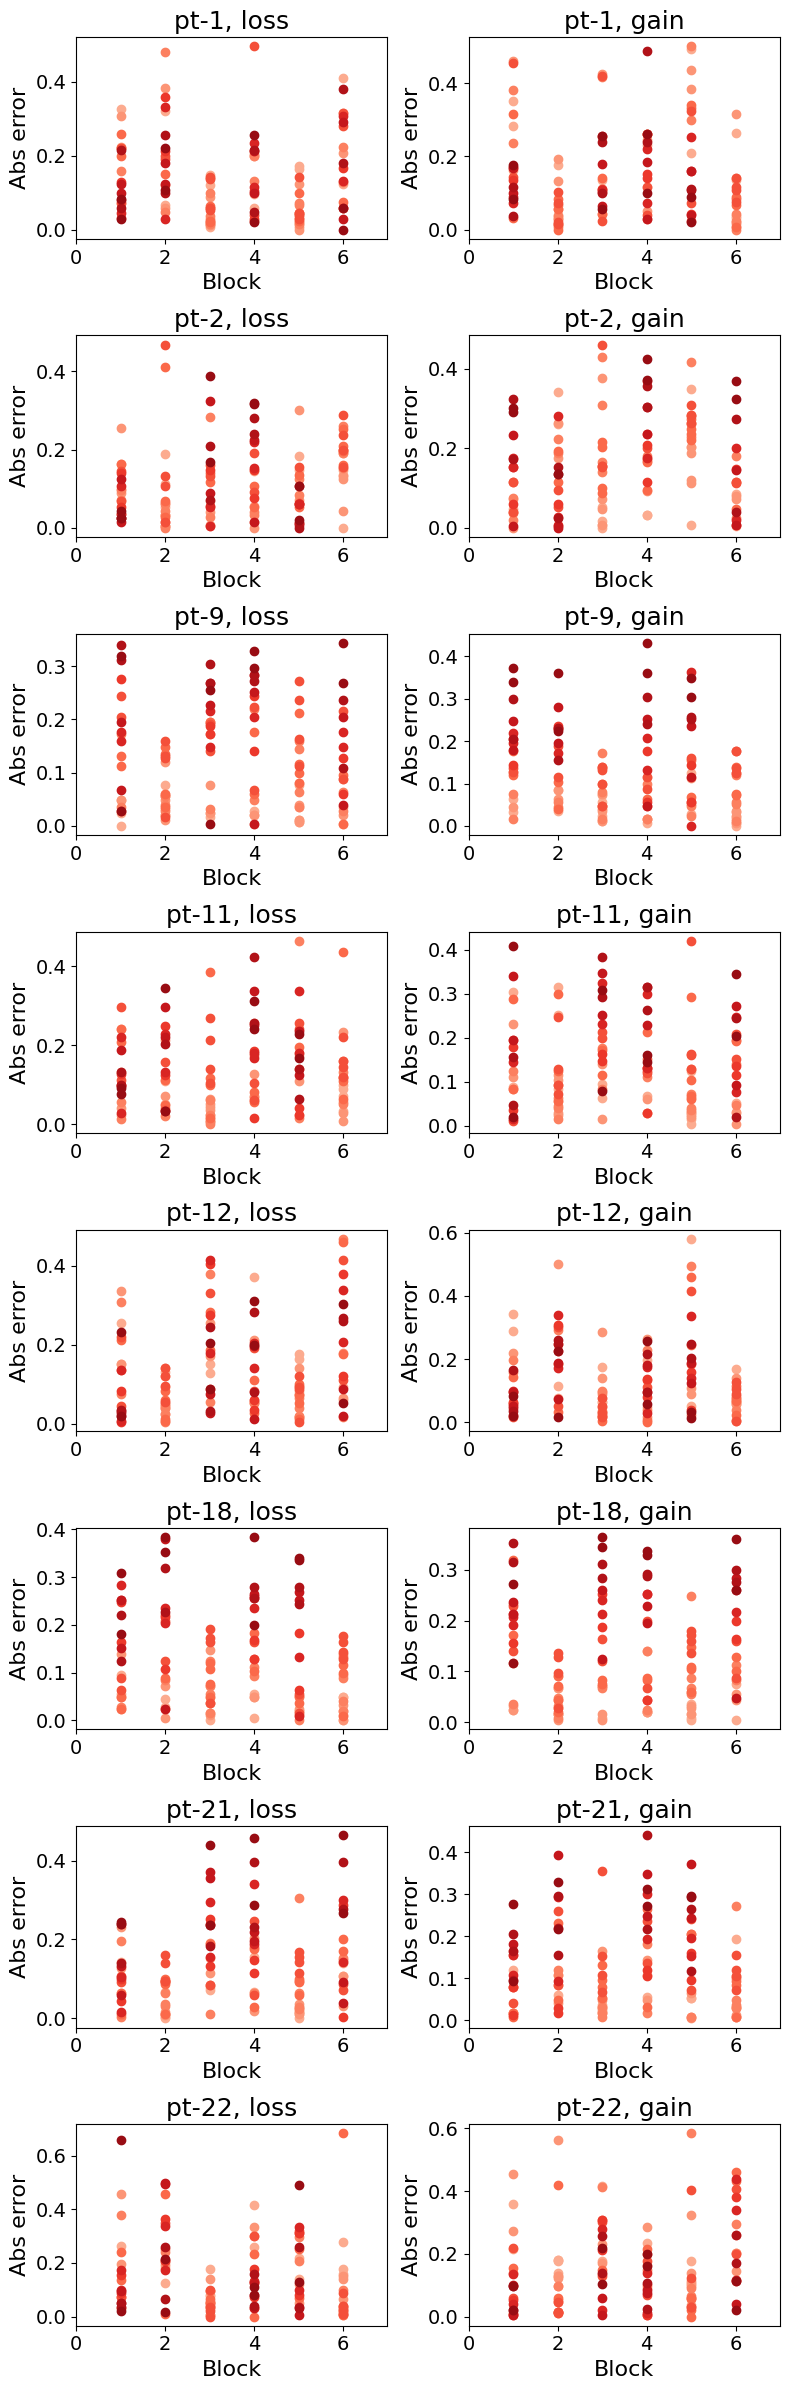

In [23]:
# choose what youre plotting
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# plot info
unique_cntxt_stims = sorted(df_analysis['stim_aligned_to_cntxt'].unique())
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(unique_cntxt_stims)))
color_map = dict(zip(unique_cntxt_stims, colors))
cntxt_rename = {'rew': 'gain', 'pen': 'loss'}
cond_rename = {'pen_comp': 'gain_exp', 'baseline': 'baseline', 'rew_comp': 'loss_exp'}
block_order = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

n_rows, n_cols = len(patients), 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axs, ax = axs.flatten(), 0
ticks, labels = np.linspace(0, .4, 5), np.linspace(0, .5, 5)

for subj in patients:

    subj_df = df_analysis[df_analysis['subj'] == subj].copy()

    for cntxt in ['pen', 'rew']: # loss on left subplots, gain on right
        cntxt_df = subj_df[subj_df['valence'] == cntxt].copy()
        
        # scatter
        for cntxt_stim, cntxt_stim_df in cntxt_df.groupby('stim_aligned_to_cntxt'):
            
            for cond in conds:
                cond_df = cntxt_stim_df[cntxt_stim_df['condition'] == cond]

                cond_df['blockN'] = pd.Categorical(cond_df['blockN'], categories=block_order, ordered=True)
                axs[ax].scatter(cond_df['blockN'], cond_df['unsigned_err'], color=color_map[cntxt_stim])
                
            # for block, block_df in cntxt_stim_df.groupby('blockN'):
            #     print(block, block_df['stim_aligned_to_cntxt'].value_counts(), end='\n\n')

            # axs[ax].scatter(cntxt_stim_df['blockN'], cntxt_stim_df['unsigned_err'], color=color_map[cntxt_stim])

            # # Calculate mean and SD of chosen position for each stimulus position
            # mean_chosen_per_stim = cntxt_stim_df.groupby('stim_aligned_to_cntxt')['unsigned_err'].agg(['mean', 'std']).reset_index()
            # mean_chosen_per_stim = mean_chosen_per_stim.sort_values('stim_aligned_to_cntxt')
            
            # # mean
            # axs[ax].plot(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], color='red')
            
            # # err bars
            # axs[ax].errorbar(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], 
            #                 yerr=mean_chosen_per_stim['std'], color=color_map[cntxt_stim])

        axs[ax].set(title=f'pt-{subj}, {cntxt_rename[cntxt]}',
                    xlabel='Block', ylabel='Abs error',
                    xlim=(0, 7))
        # axs[0].legend()
        ax += 1

# fig.subplots_adjust(wspace=.8, hspace=.4, top=.94)
plt.tight_layout()
plt.show()


1.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

2.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.02    4
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

5.0 stim_aligned_to_cntxt
0.02    4
Name: count, dtype: int64

6.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

1.0 stim_aligned_to_cntxt
0.06    2
Name: count, dtype: int64

2.0 stim_aligned_to_cntxt
0.06    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.06    4
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.06    2
Name: count, dtype: int64

5.0 stim_aligned_to_cntxt
0.06    4
Name: count, dtype: int64

6.0 stim_aligned_to_cntxt
0.06    2
Name: count, dtype: int64

1.0 stim_aligned_to_cntxt
0.1    2
Name: count, dtype: int64

2.0 stim_aligned_to_cntxt
0.1    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.1    4
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.1    2
Name: count, dtype: int

1.0 stim_aligned_to_cntxt
0.3    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.3    2
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.3    2
Name: count, dtype: int64

6.0 stim_aligned_to_cntxt
0.3    2
Name: count, dtype: int64

1.0 stim_aligned_to_cntxt
0.34    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.34    2
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.34    2
Name: count, dtype: int64

6.0 stim_aligned_to_cntxt
0.34    2
Name: count, dtype: int64

1.0 stim_aligned_to_cntxt
0.38    2
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.38    2
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.38    2
Name: count, dtype: int64

6.0 stim_aligned_to_cntxt
0.38    2
Name: count, dtype: int64

1.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

2.0 stim_aligned_to_cntxt
0.02    4
Name: count, dtype: int64

3.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int64

4.0 stim_aligned_to_cntxt
0.02    2
Name: count, dtype: int

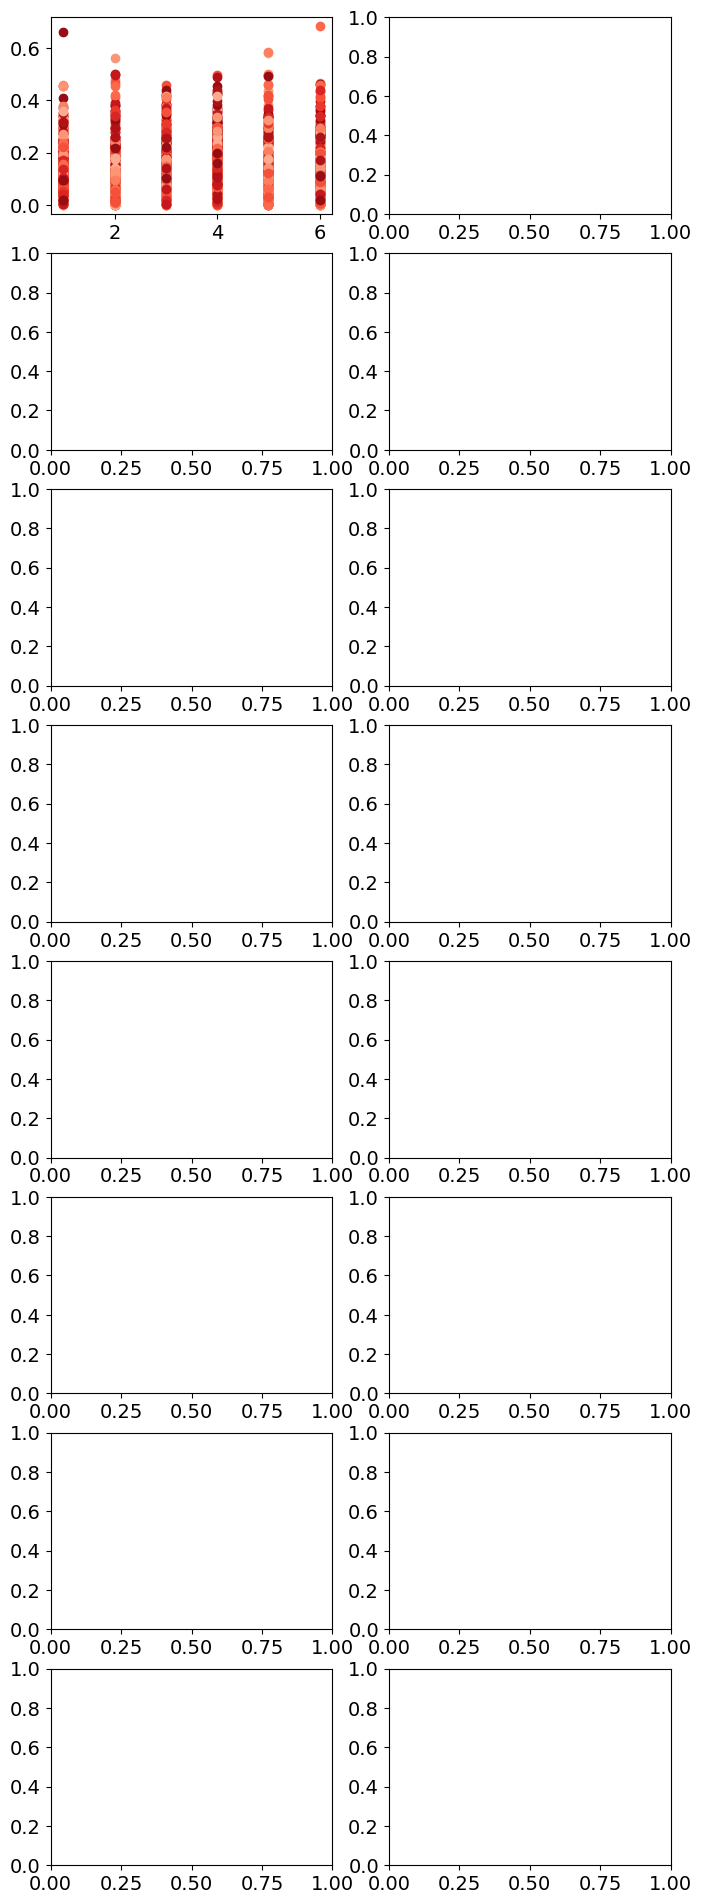

In [24]:
# choose what youre plotting
subj_or_pop, df_analysis = get_df(df_clean, 'pop')

# plot info
unique_cntxt_stims = sorted(df_analysis['stim_aligned_to_cntxt'].unique())
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(unique_cntxt_stims)))
color_map = dict(zip(unique_cntxt_stims, colors))
cntxt_rename = {'rew': 'gain', 'pen': 'loss'}

n_rows, n_cols = len(patients), 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axs, ax = axs.flatten(), 0
ticks, labels = np.linspace(0, .4, 5), np.linspace(0, .5, 5)

for subj in patients:

    subj_df = df_analysis[df_analysis['subj'] == subj].copy()

    for cntxt in ['pen', 'rew']: # loss on left, gain on right
        cntxt_df = subj_df[subj_df['valence'] == cntxt].copy()
                    
        # plot
        for cntxt_stim, cntxt_stim_df in cntxt_df.groupby('stim_aligned_to_cntxt'):

            for block, block_df in cntxt_stim_df.groupby('blockN'):
                print(block, block_df['stim_aligned_to_cntxt'].value_counts(), end='\n\n')

            axs[ax].scatter(cntxt_stim_df['blockN'], cntxt_stim_df['unsigned_err'], color=color_map[cntxt_stim])

            # # Calculate mean and SD of chosen position for each stimulus position
            # mean_chosen_per_stim = cntxt_stim_df.groupby('stim_aligned_to_cntxt')['unsigned_err'].agg(['mean', 'std']).reset_index()
            # mean_chosen_per_stim = mean_chosen_per_stim.sort_values('stim_aligned_to_cntxt')
            
            # # mean
            # axs[ax].plot(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], color='red')
            
            # # err bars
            # axs[ax].errorbar(mean_chosen_per_stim['stim_aligned_to_cntxt'], mean_chosen_per_stim['mean'], 
           